In [1]:
import numpy as np
from pathlib import Path
import itertools
import vedo
from bg_atlasapi.bg_atlas import BrainGlobeAtlas
import pickle
import os
import pandas as pd

import brainrender
from brainrender import Scene
import matplotlib.pyplot as plt

vedo.settings.default_backend = "vtk"

In [19]:
dt_folder = Path(r"J:\project_trainingAggression\Data")

probeAlignedAnatomy = [f for f in dt_folder.rglob("*histologyAlignedData.npy")]

all_alignHist = []

for probe in probeAlignedAnatomy:
    alignHist = np.load(probe, allow_pickle=True)
    all_alignHist.append(alignHist)

In [16]:

with open(probesHERBSpath[2], "rb") as f:
    probe = pickle.load(f)


atlas = BrainGlobeAtlas("allen_mouse_50um")
annot = atlas.annotation

vox = np.asarray(probe["data"]["sites_vox"]).reshape(-1, 3)
labels = np.asarray(probe["data"]["sites_label"]).reshape(-1)

print("BrainGlobe annotation shape:", annot.shape)
print("HERBS voxel min:", vox.min(axis=0))
print("HERBS voxel max:", vox.max(axis=0))

perms = list(itertools.permutations([0, 1, 2]))

results = []

for perm in perms:
    v = vox[:, perm].copy()

    for flips in itertools.product([False, True], repeat=3):
        vv = v.copy()

        for ax, do_flip in enumerate(flips):
            if do_flip:
                vv[:, ax] = annot.shape[ax] - 1 - vv[:, ax]

        valid = np.all((vv >= 0) & (vv < np.array(annot.shape)), axis=1)

        if valid.sum() == 0:
            continue

        vv_valid = vv[valid].astype(int)
        labels_valid = labels[valid]

        atlas_labels = annot[
            vv_valid[:, 0],
            vv_valid[:, 1],
            vv_valid[:, 2]
        ]

        match = atlas_labels == labels_valid
        score = match.mean()

        results.append({
            "perm": perm,
            "flips": flips,
            "valid_n": valid.sum(),
            "score": score,
            "matches": match.sum()
        })

results = sorted(results, key=lambda x: x["score"], reverse=True)

for r in results[:10]:
    print(r)

BrainGlobe annotation shape: (264, 160, 228)
HERBS voxel min: [69 74 60]
HERBS voxel max: [115  75 145]
{'perm': (1, 2, 0), 'flips': (True, True, False), 'valid_n': np.int64(484), 'score': np.float64(1.0), 'matches': np.int64(484)}
{'perm': (1, 2, 0), 'flips': (True, True, True), 'valid_n': np.int64(484), 'score': np.float64(0.8119834710743802), 'matches': np.int64(393)}
{'perm': (0, 2, 1), 'flips': (True, True, True), 'valid_n': np.int64(484), 'score': np.float64(0.1322314049586777), 'matches': np.int64(64)}
{'perm': (0, 2, 1), 'flips': (True, True, False), 'valid_n': np.int64(484), 'score': np.float64(0.12603305785123967), 'matches': np.int64(61)}
{'perm': (1, 2, 0), 'flips': (True, False, True), 'valid_n': np.int64(484), 'score': np.float64(0.12396694214876033), 'matches': np.int64(60)}
{'perm': (1, 2, 0), 'flips': (True, False, False), 'valid_n': np.int64(484), 'score': np.float64(0.11570247933884298), 'matches': np.int64(56)}
{'perm': (2, 1, 0), 'flips': (True, False, False), 'val

In [9]:
dt_folder = Path(r"J:\project_trainingAggression\Data")
probeAlignedAnatomy = sorted(dt_folder.rglob("*histologyAlignedData.npy"))

atlas = BrainGlobeAtlas("allen_mouse_50um")

# ------------------------------------------------------------
# Load all histology-aligned anatomy arrays
# ------------------------------------------------------------

all_rows = []

for probe in probeAlignedAnatomy:
    alignHist = np.load(probe, allow_pickle=True)
    alignHist = np.asarray(alignHist, dtype=object)

    df = pd.DataFrame(
        alignHist[:, :3],
        columns=["structure_id", "acronym", "name"]
    )

    df["probe"] = probe.stem
    all_rows.append(df)

all_df = pd.concat(all_rows, ignore_index=True)

all_df = all_df[
    (all_df["structure_id"].astype(str) != "0") &
    (all_df["acronym"].astype(str).str.strip() != "")
].copy()

all_df["structure_id"] = all_df["structure_id"].astype(int)

# ------------------------------------------------------------
# Count anatomy sites across all probes
# ------------------------------------------------------------

counts = (
    all_df.groupby(["structure_id", "acronym", "name"])
    .size()
    .reset_index(name="cell_count")
    .sort_values("cell_count", ascending=False)
)

display(counts)

# ------------------------------------------------------------
# Remove parent regions if child regions are also present
# ------------------------------------------------------------

detected_ids = set(counts["structure_id"].astype(int))

def get_structure_path(sid):
    try:
        path = atlas.structures[int(sid)]["structure_id_path"]
    except Exception:
        return []

    if isinstance(path, str):
        path = [
            int(x) for x in path
            .replace("[", "")
            .replace("]", "")
            .replace("/", " ")
            .replace(",", " ")
            .split()
            if x.strip().isdigit()
        ]

    return [int(x) for x in path]

parent_ids_to_remove = set()

for parent_id in detected_ids:
    for child_id in detected_ids:
        if parent_id == child_id:
            continue

        child_path = get_structure_path(child_id)

        if int(parent_id) in child_path:
            parent_ids_to_remove.add(parent_id)
            break

counts_render = counts[
    ~counts["structure_id"].astype(int).isin(parent_ids_to_remove)
].copy()

# ------------------------------------------------------------
# Remove broad scaffolding / white matter / whole-brain-like regions
# ------------------------------------------------------------

exclude_acronyms = {
    "root", "grey", "CH", "CTX", "CTXpl", "Isocortex",
    "OLF", "HPF", "CNU", "STR", "PAL", "TH", "HY", "MB",
    "HB", "BS", "CB", "VS", "fiber tracts", "arb",

    # white matter / tracts that make large outlines or scaffolds
    "ccb", "cc", "ccg", "fa", "ec", "ee", "fp", "or",
    "scwm", "int", "fi", "fx", "em", "mlf", "scp",
    "dscp", "tspc", "act", "aco", "st", "cing", "mtg",
}

counts_render = counts_render[
    ~counts_render["acronym"].astype(str).str.strip().isin(exclude_acronyms)
].copy()

display(counts_render)

# ------------------------------------------------------------
# Create brainrender scene
# ------------------------------------------------------------

scene = Scene(
    atlas_name="allen_mouse_50um",
    inset=False,
    title=None,
)

# ------------------------------------------------------------
# Add ONLY represented regions
# ------------------------------------------------------------

max_count = counts_render["cell_count"].max()

rendered = []
skipped = []

for _, row in counts_render.iterrows():

    acronym = str(row["acronym"]).strip()
    n = int(row["cell_count"])

    alpha = 0.20 + 0.90 * (n / max_count)

    try:
        actor = scene.add_brain_region(
            acronym,
            alpha=alpha,
        )

        actors = actor if isinstance(actor, (list, tuple)) else [actor]

        for a in actors:
            try:
                a.wireframe(False)
            except Exception:
                pass

            try:
                a.linewidth(0)
            except Exception:
                pass

            try:
                a.lw(0)
            except Exception:
                pass

            try:
                a.lighting("plastic")
            except Exception:
                pass

            try:
                a.smooth()
            except Exception:
                pass

        rendered.append(acronym)

    except Exception as e:
        skipped.append((acronym, str(e)))

# ------------------------------------------------------------
# Aggressively remove outer brain / root / outline actors
# ------------------------------------------------------------

for actor in list(scene.actors):

    remove_actor = False

    try:
        nm = str(actor.name).lower()
    except Exception:
        nm = ""

    if any(
        key in nm
        for key in [
            "root",
            "outline",
            "brain",
            "bounding",
            "wire",
            "axis",
            "axes",
            "inset",
        ]
    ):
        remove_actor = True

    # remove very transparent default background actors
    try:
        if actor.alpha() <= 0.05:
            remove_actor = True
    except Exception:
        pass

    if remove_actor:
        try:
            scene.remove(actor)
        except Exception:
            pass

# ------------------------------------------------------------
# Force all remaining actors to have no black contours
# ------------------------------------------------------------

for actor in list(scene.actors):

    try:
        actor.wireframe(False)
    except Exception:
        pass

    try:
        actor.linewidth(0)
    except Exception:
        pass

    try:
        actor.lw(0)
    except Exception:
        pass

    try:
        actor.lighting("plastic")
    except Exception:
        pass

print(f"Rendered {len(rendered)} specific regions")
print(f"Skipped {len(skipped)} regions")

if len(skipped) > 0:
    print("\nSkipped regions:\n")
    for acr, err in skipped:
        print(acr, "->", err)

# ------------------------------------------------------------
# Render
# ------------------------------------------------------------

scene.render()

,structure_id,acronym,name,cell_count
43,672,CP,Caudoputamen,470
11,128,MRN,Midbrain reticular nucleus,356
55,795,PAG,Periaqueductal gray,263
17,262,RT,Reticular nucleus of the thalamus,226
16,258,LSr,Lateral septal nucleus rostral (rostroventral)...,194
...,...,...,...,...
72,940,cing,cingulum bundle,3
80,1092,em,external medullary lamina of the thalamus,2
60,819,ACAv6b,Anterior cingulate area ventral part 6b,2
38,593,VISp1,Primary visual area layer 1,1


,structure_id,acronym,name,cell_count
43,672,CP,Caudoputamen,470
11,128,MRN,Midbrain reticular nucleus,356
17,262,RT,Reticular nucleus of the thalamus,226
16,258,LSr,Lateral septal nucleus rostral (rostroventral)...,194
73,945,SSp-ul6a,Primary somatosensory area upper limb layer 6a,132
...,...,...,...,...
26,430,RSPv2/3,Retrosplenial area ventral part layer 2/3,3
91,614454277,Su3,Supraoculomotor periaqueductal gray,3
60,819,ACAv6b,Anterior cingulate area ventral part 6b,2
38,593,VISp1,Primary visual area layer 1,1


Rendered 70 specific regions
Skipped 0 regions


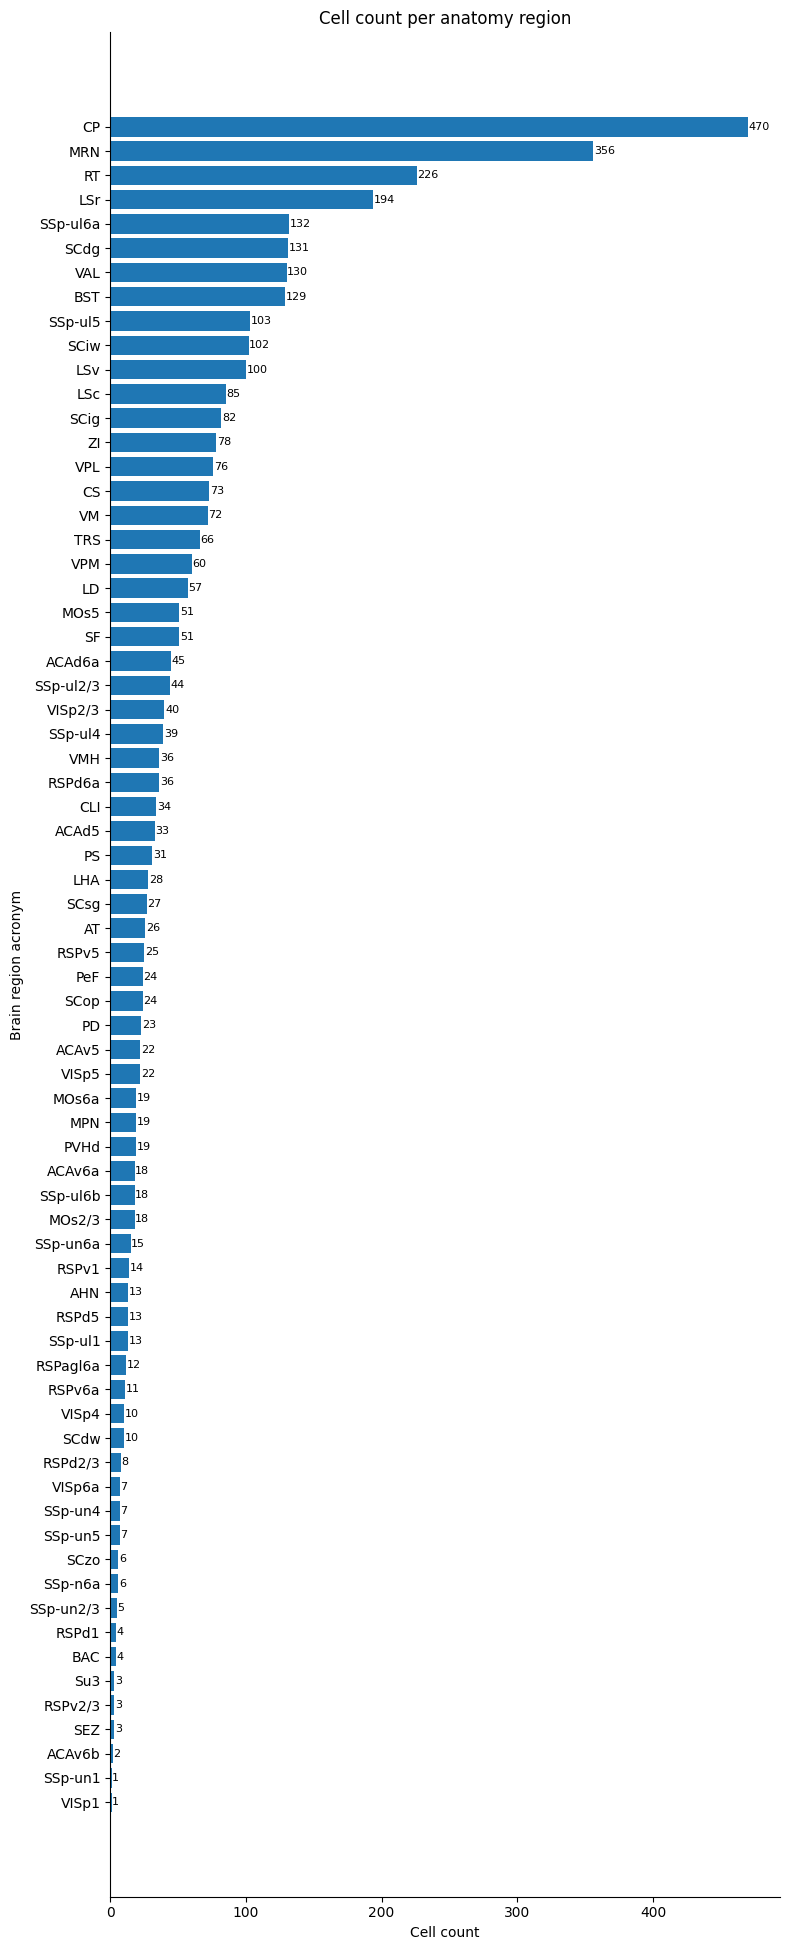

In [10]:
counts_bar = counts_render.sort_values("cell_count", ascending=True).copy()

fig, ax = plt.subplots(figsize=(8, max(5, 0.28 * len(counts_bar))))

ax.barh(
    counts_bar["acronym"].astype(str),
    counts_bar["cell_count"]
)

ax.set_xlabel("Cell count")
ax.set_ylabel("Brain region acronym")
ax.set_title("Cell count per anatomy region")

for i, v in enumerate(counts_bar["cell_count"]):
    ax.text(
        v + 0.5,
        i,
        str(int(v)),
        va="center",
        fontsize=8
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()